In [1]:
!pip install pymongo pandas numpy

In [4]:
from pymongo import MongoClient
import pandas as pd
import numpy as np

# Conexión a MongoDB
client = MongoClient("mongodb://localhost:27017/")

# Base de datos y colección
db = client["COVID"]
coleccion = db["puebla"]

# Obtener edades
datos = list(
    coleccion.find(
        {"EDAD": {"$exists": True}},
        {"_id": 0, "EDAD": 1}
    )
)

# Crear DataFrame
df = pd.DataFrame(datos)

# Estadísticas básicas
print("Cantidad:", len(df))
print("Mínimo:", df["EDAD"].min())
print("Máximo:", df["EDAD"].max())
print("Promedio:", df["EDAD"].mean())
print("Mediana:", df["EDAD"].median())
print("Varianza:", df["EDAD"].var())

Cantidad: 706207
Mínimo: 0
Máximo: 122
Promedio: 39.76099925375988
Mediana: 38.0
Varianza: 335.12658983079524


In [3]:
q1 = df["EDAD"].quantile(0.25)
q2 = df["EDAD"].quantile(0.50)
q3 = df["EDAD"].quantile(0.75)

print("Q1:", q1)
print("Q2 (Mediana):", q2)
print("Q3:", q3)

Q1: 27.0
Q2 (Mediana): 38.0
Q3: 52.0


In [4]:
print("Percentil 10:", np.percentile(df["EDAD"], 10))
print("Percentil 25:", np.percentile(df["EDAD"], 25))
print("Percentil 50:", np.percentile(df["EDAD"], 50))
print("Percentil 75:", np.percentile(df["EDAD"], 75))
print("Percentil 90:", np.percentile(df["EDAD"], 90))

Percentil 10: 19.0
Percentil 25: 27.0
Percentil 50: 38.0
Percentil 75: 52.0
Percentil 90: 65.0


In [6]:
estadisticas = df["EDAD"].describe()

estadisticas.index = [
    "Cantidad",
    "Promedio",
    "Desviación estándar",
    "Mínimo",
    "Primer cuartil (25%)",
    "Mediana (50%)",
    "Tercer cuartil (75%)",
    "Máximo"
]

print(estadisticas)

Cantidad                706207.000000
Promedio                    39.760999
Desviación estándar         18.306463
Mínimo                       0.000000
Primer cuartil (25%)        27.000000
Mediana (50%)               38.000000
Tercer cuartil (75%)        52.000000
Máximo                     122.000000
Name: EDAD, dtype: float64


335.12658983079524


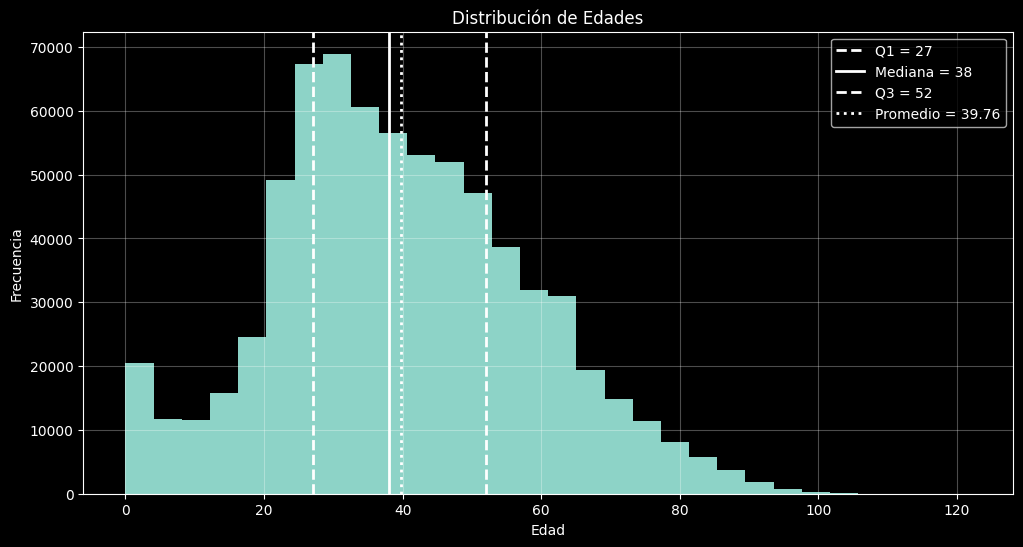

In [10]:
import matplotlib.pyplot as plt

# Calcular estadísticas
q1 = df["EDAD"].quantile(0.25)
q2 = df["EDAD"].median()
q3 = df["EDAD"].quantile(0.75)
promedio = df["EDAD"].mean()

# Crear gráfico
plt.figure(figsize=(12,6))

plt.hist(df["EDAD"], bins=30)
plt.style.use('dark_background')
plt.gca().set_facecolor('#000000')  # Fondo de la gráfica


# Líneas de referencia
plt.axvline(q1, linestyle='--', linewidth=2, label=f'Q1 = {q1:.0f}')
plt.axvline(q2, linestyle='-', linewidth=2, label=f'Mediana = {q2:.0f}')
plt.axvline(q3, linestyle='--', linewidth=2, label=f'Q3 = {q3:.0f}')
plt.axvline(promedio, linestyle=':', linewidth=2,
            label=f'Promedio = {promedio:.2f}')

plt.title('Distribución de Edades')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

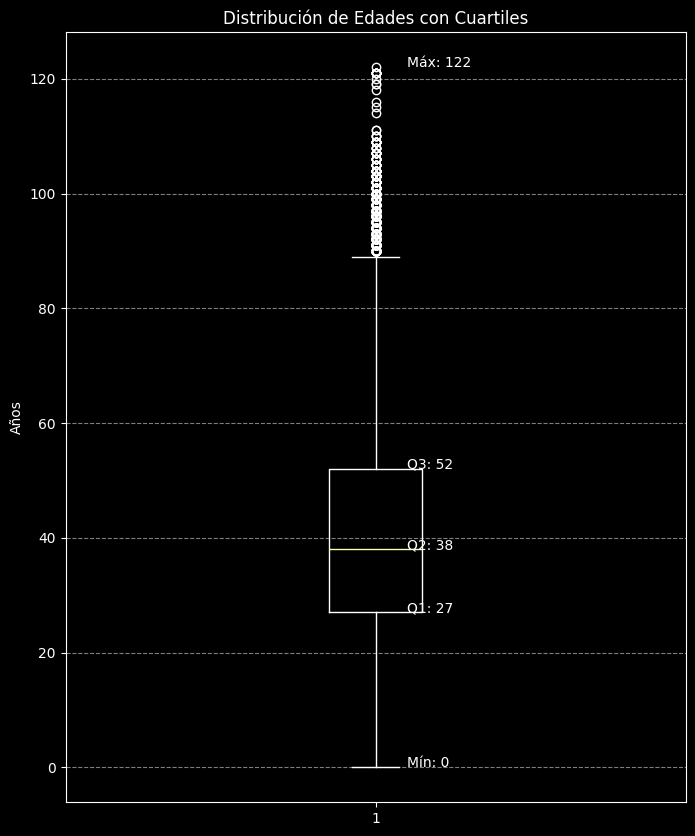

In [13]:
import matplotlib.pyplot as plt

edad = df["EDAD"]

q1 = edad.quantile(0.25)
q2 = edad.quantile(0.50)
q3 = edad.quantile(0.75)

plt.figure(figsize=(8,10))
plt.boxplot(edad, vert=True)
plt.gca().set_facecolor('#000000')  # Fondo de la gráfica

plt.title("Distribución de Edades con Cuartiles")
plt.ylabel("Años")


plt.annotate(f"Q1: {q1:.0f}", (1.05, q1))
plt.annotate(f"Q2: {q2:.0f}", (1.05, q2))
plt.annotate(f"Q3: {q3:.0f}", (1.05, q3))
plt.annotate(f"Mín: {edad.min():.0f}", (1.05, edad.min()))
plt.annotate(f"Máx: {edad.max():.0f}", (1.05, edad.max()))

plt.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.show()

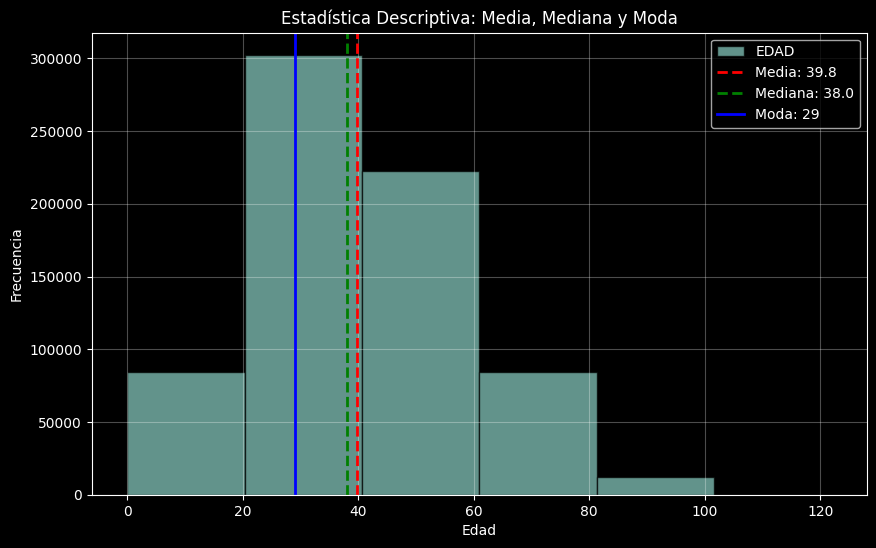